In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/china_gdp.csv'

df = pd.read_csv(url)
df.head(10)


,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


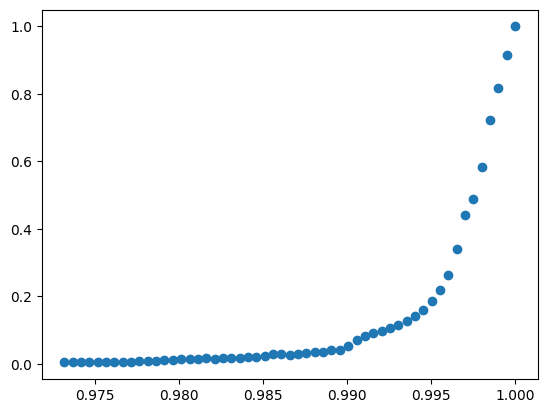

In [3]:
x = np.asanyarray(df[['Year']]/df.Year.max())
y = np.asanyarray(df[['Value']]/df.Value.max())

plt.scatter(x, y)

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x,y)



LinearRegression()

In [5]:
ythat = model.predict(x)

In [6]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y,ythat))

0.12657979406214762


In [10]:
from sklearn.preprocessing import PolynomialFeatures

play_features = PolynomialFeatures(degree=5, include_bias=False)
x_poly = play_features.fit_transform(x)


In [13]:
model.fit(x_poly,y)

LinearRegression()

In [14]:
ythat = model.predict(x_poly)

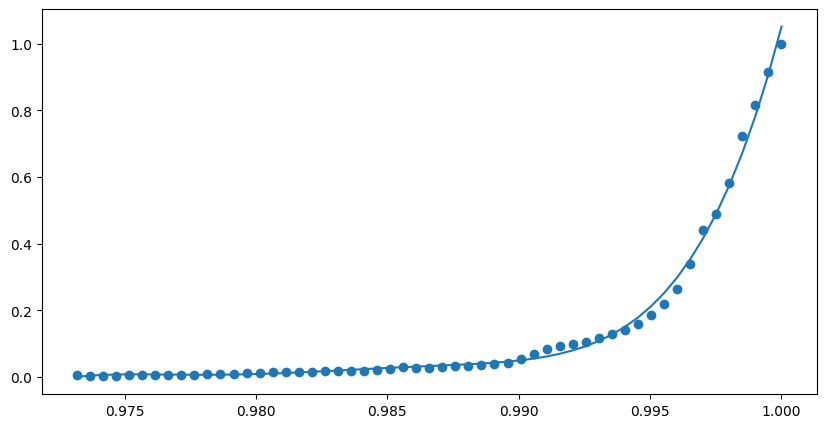

In [15]:
plt.figure(figsize=(10,5))
plt.scatter(x,y)
plt.plot(x,ythat)

In [16]:
x_data, y_data = (df['Year'].values, df['Value'].values)
xdata = x_data/max(x_data)
ydata = y_data/max(y_data)

In [17]:
def sigmoid(x, Beta_1, Beta_2):
    y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
    return y

In [19]:
from scipy.optimize import curve_fit

beta,pcov = curve_fit(sigmoid, xdata, ydata)
print(f'beta1={beta[0]}/nbeta2 ={beta[1]}')

beta1=690.4517083847173/nbeta2 =0.9972071272536834


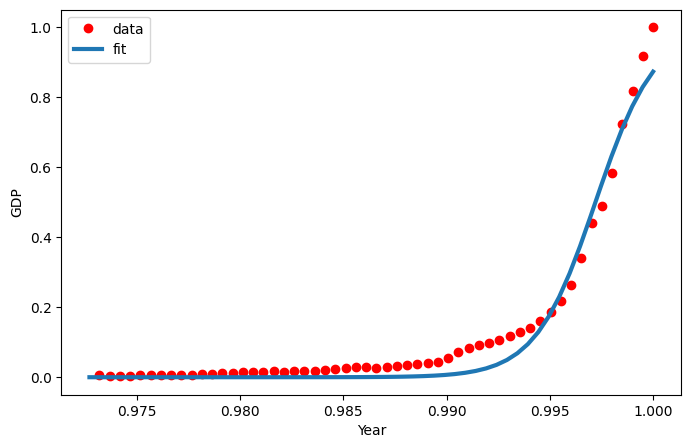

In [20]:
x = np.linspace(1960,2015,55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x,*beta)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()